https://www.kaggle.com/datasets/teamincribo/cyber-security-attacks/data?select=cybersecurity_attacks.csv



In [5]:
!mkdir -p notebooks artifacts data


In [6]:
import os, shutil

source_dir = "/content/drive/MyDrive/Colab Notebooks"
target = "notebooks/01_data_preparation_and_understanding.ipynb"

for f in os.listdir(source_dir):
    if "projeto cyber notebook 1" in f.lower() and "oficial" in f.lower():
        shutil.copy(os.path.join(source_dir, f), target)
        print("Notebook copiado:", f)
        break


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks'

# **Etapa 0 - Setup and Load Data**


In [ ]:
# Bibliotecas principais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais
plt.style.use("default")
pd.set_option("display.max_columns", None)

# Google Drive
from google.colab import drive
drive.mount('/content/drive')


In [22]:
DATA_DIR = "data"
ARTIFACTS_DIR = "artifacts"

os.makedirs(ARTIFACTS_DIR, exist_ok=True)


In [7]:
# Load dataset
path = "/content/drive/MyDrive/cybersecurity_attacks.csv"
df = pd.read_csv(path)

print("Dimensão do dataset:", df.shape)
df.head()


NameError: name 'pd' is not defined

# **1. Business Understanding (Markdown)**


## Business Understanding

O objetivo deste projeto é desenvolver um sistema de Machine Learning para apoio
à deteção e análise de ataques cibernéticos, respondendo a três questões centrais:

1. O evento corresponde a um ataque?
2. Qual é o tipo de ataque identificado?
3. O comportamento observado é novo ou anómalo?

Esta abordagem reflete a arquitetura típica de sistemas de cibersegurança
utilizados em SOCs (Security Operations Centers).


# **2. Data Understanding**

## **Estrutura geral**

In [27]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Timestamp               40000 non-null  object 
 1   Source IP Address       40000 non-null  object 
 2   Destination IP Address  40000 non-null  object 
 3   Source Port             40000 non-null  int64  
 4   Destination Port        40000 non-null  int64  
 5   Protocol                40000 non-null  object 
 6   Packet Length           40000 non-null  int64  
 7   Packet Type             40000 non-null  object 
 8   Traffic Type            40000 non-null  object 
 9   Payload Data            40000 non-null  object 
 10  Malware Indicators      20000 non-null  object 
 11  Anomaly Scores          40000 non-null  float64
 12  Alerts/Warnings         19933 non-null  object 
 13  Attack Type             40000 non-null  object 
 14  Attack Signature        40000 non-null

## **Tipos de dados**

In [28]:
df.dtypes


,0
Timestamp,object
Source IP Address,object
Destination IP Address,object
Source Port,int64
Destination Port,int64
Protocol,object
Packet Length,int64
Packet Type,object
Traffic Type,object
Payload Data,object


## **Valores em falta**

In [29]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]


,0
Alerts/Warnings,20067
IDS/IPS Alerts,20050
Malware Indicators,20000
Firewall Logs,19961
Proxy Information,19851


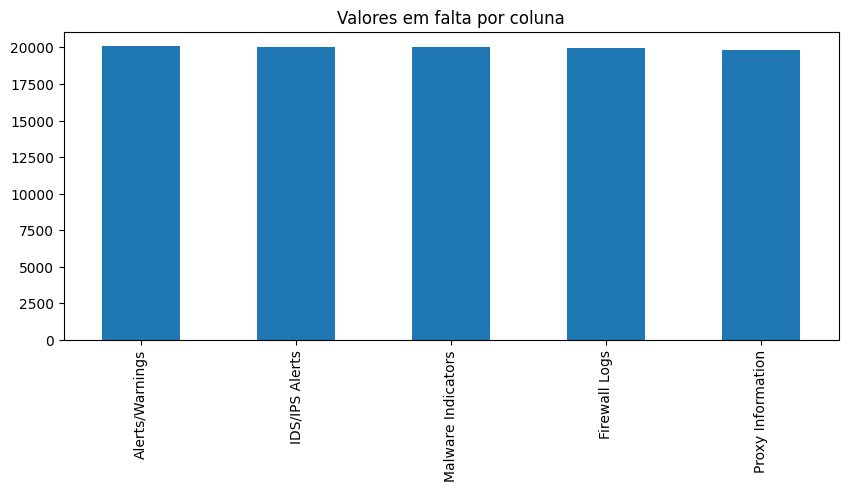

In [30]:
plt.figure(figsize=(10,4))
missing[missing > 0].plot(kind='bar')
plt.title("Valores em falta por coluna")
plt.show()


## **Estatísticas descritivas**

In [31]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Timestamp,40000,39997,2022-06-11 14:28:15,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Source IP Address,40000,40000,138.156.5.40,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Destination IP Address,40000,40000,91.54.135.213,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Source Port,40000.0,NaN,NaN,NaN,32970.35645,18560.425604,1027.0,16850.75,32856.0,48928.25,65530.0
Destination Port,40000.0,NaN,NaN,NaN,33150.86865,18574.668842,1024.0,17094.75,33004.5,49287.0,65535.0
Protocol,40000,3,ICMP,13429,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Packet Length,40000.0,NaN,NaN,NaN,781.452725,416.044192,64.0,420.0,782.0,1143.0,1500.0
Packet Type,40000,2,Control,20237,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Traffic Type,40000,3,DNS,13376,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Payload Data,40000,40000,Fugiat tenetur natus perferendis. Mollitia bla...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# **3.Targets**

## **Target 1 – Vai ser ataque?**

In [32]:
df["Is_Attack"] = 1

## **Target 2 – Tipo de ataque**

In [33]:
TARGET_ATTACK_TYPE = "Attack Type"

# Segurança extra
assert TARGET_ATTACK_TYPE in df.columns, "Target de ataque não existe!"

## **Target 3 – É algo novo?**

Não é supervisionado, logo:

não criamos coluna target

apenas preparamos os dados

# **4. Data Quality Checks**

Duplicados

In [34]:
print("Linhas duplicadas:", df.duplicated().sum())

df = df.drop_duplicates()
print("Nova dimensão:", df.shape)

Linhas duplicadas: 0
Nova dimensão: (40000, 26)


Valores constantes

In [35]:
constant_cols = [c for c in df.columns if df[c].nunique() == 1]
constant_cols

df.drop(columns=constant_cols, inplace=True)





# **5. Feature / Target Separation**

In [36]:
# TARGETS DO PROJETO
TARGET_ATTACK_TYPE = "Attack Type"
df["Is_Attack"] = 1


# Confirmação de segurança
assert TARGET_ATTACK_TYPE in df.columns, "Attack Type não existe no dataset!"


In [37]:
FEATURES = df.drop(
    columns=["Is_Attack", TARGET_ATTACK_TYPE]
)

y_is_attack = df["Is_Attack"]
y_attack_type = df[TARGET_ATTACK_TYPE]

print("Features:", FEATURES.shape)
print("Is_Attack:", y_is_attack.shape)
print("Attack_Type:", y_attack_type.shape)


Features: (40000, 20)
Is_Attack: (40000,)
Attack_Type: (40000,)


## **6. Feature Analysis**

In [38]:
cat_cols = FEATURES.select_dtypes(include=["object"]).columns.tolist()
num_cols = FEATURES.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Variáveis categóricas:", len(cat_cols))
print("Variáveis numéricas:", len(num_cols))


Variáveis categóricas: 16
Variáveis numéricas: 4


# **7. Data Preparation**

## **7A.Encoding + Scaling (sem treinar modelo)**

In [39]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols) # One-Hot Encoding apenas para modelos sklearn (não usado em TensorFlow)

    ]
)


Teste rápido:

In [40]:
X_transformed = preprocessor.fit_transform(FEATURES)
print("Shape após preprocessing:", X_transformed.shape)


Shape após preprocessing: (40000, 253387)


## **7B. Data Preparation para TensorFlow**

In [41]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib

# Cópia para TensorFlow
df_tf = FEATURES.copy()

label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df_tf[col] = le.fit_transform(df_tf[col].astype(str))
    label_encoders[col] = le

print("Encoding categórico para TensorFlow concluído.")


Encoding categórico para TensorFlow concluído.


In [42]:
scaler_tf = StandardScaler()
df_tf[num_cols] = scaler_tf.fit_transform(df_tf[num_cols])

print("Normalização numérica para TensorFlow concluída.")


Normalização numérica para TensorFlow concluída.


## **7C. Dataset final para TensorFlow**

In [43]:
X_tf = df_tf.values
y_attack_tf = y_attack_type.values



print("X_tf shape:", X_tf.shape)
print("y_attack_tf shape:", y_attack_tf.shape)


X_tf shape: (40000, 20)
y_attack_tf shape: (40000,)


In [44]:
from sklearn.preprocessing import LabelEncoder

# Encoding do target (Attack Type) para TensorFlow
label_encoder_attack = LabelEncoder()
y_attack_tf = label_encoder_attack.fit_transform(y_attack_type)

print("Classes de ataque:", label_encoder_attack.classes_)
print("y_attack_tf shape:", y_attack_tf.shape)


Classes de ataque: ['DDoS' 'Intrusion' 'Malware']
y_attack_tf shape: (40000,)


# **8. Preparação específica para Novelty Detection**

 Isolation Forest não precisa de labels.
                          Usa apenas as features.
                           O treino do modelo de deteção de anomalias será realizado no Notebook 2.


Guardamos uma versão numérica + categórica codificada.

In [45]:
X_novelty = X_transformed


## **8B. Preparação para Novelty Detection (TensorFlow)**

In [46]:
X_tf_novelty = X_tf


# **9.Guardar Dados para o Notebook 2**

In [47]:
import joblib

joblib.dump(preprocessor, "/content/drive/MyDrive/preprocessor.pkl")
joblib.dump(cat_cols, "/content/drive/MyDrive/cat_cols.pkl")
joblib.dump(num_cols, "/content/drive/MyDrive/num_cols.pkl")

df.to_csv("/content/drive/MyDrive/df_clean.csv", index=False)


## **9B. Guardar artefactos para TensorFlow**

In [48]:
np.save("/content/drive/MyDrive/X_tf.npy", X_tf)
np.save("/content/drive/MyDrive/y_attack_tf.npy", y_attack_tf)

joblib.dump(
    label_encoder_attack,
    "/content/drive/MyDrive/label_encoder_attack_tf.pkl"
)


['/content/drive/MyDrive/label_encoder_attack_tf.pkl']

# **10. Conclusões (Markdown)**

## Conclusões – Data Understanding & Preparation

- O dataset contém exclusivamente eventos de ataque, o que limita a aprendizagem
  supervisionada do problema “Vai ser ataque?”, sendo esta limitação explicitada.
- O tipo de ataque apresenta labels bem definidas, adequadas a classificação multiclasse.
- A deteção de comportamentos novos será tratada como um problema de deteção de anomalias,
  não supervisionado.
- Os dados foram preparados de forma modular, permitindo suportar múltiplos modelos
  no Notebook 2.
-----------------------------------------------------------------
- Após o ajuste o Notebook passa a produzir 2 diferentes datasets